# Polynominal regression

## Task

- Load dataset with sizes and prices
- Explore and display the data
- Create a linear model and find out its R2
- Create polynomial models with different degrees, find their R2
- Select the best model 

# Data loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

In [2]:
data = pd.read_csv ("..\dataset\prices.csv",  sep=';')

# Linear model
- standardize the data
- create and train a linear model
- display model parameters
- visualize the linear model
- display model scores

Dataset:
        Size       Price
0   51.00000   901.18810
1   70.36735   972.23867
2   89.73469  1001.99394
3  109.10204  1024.90830
4  128.46939  1053.72491
5  147.83673  1127.36215
6  167.20408  1128.96012
7  186.57143  1184.53350
8  205.93878  1124.27757
9  225.30612  1201.18979

Basic statistics:
              Size        Price
count    62.000000    62.000000
mean    641.704081  1327.839685
std     349.418285   148.292994
min      51.000000   901.188100
25%     346.352037  1241.288570
50%     641.704085  1358.216850
75%     937.056123  1447.718920
max    1232.408156  1527.818240


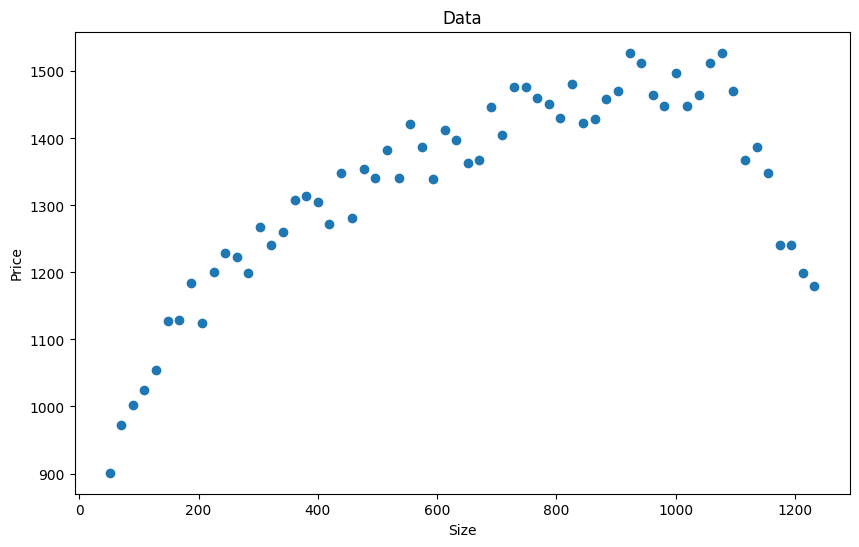


Linear Model Parameters:
Coefficient: 100.2024
Intercept: 1327.8397


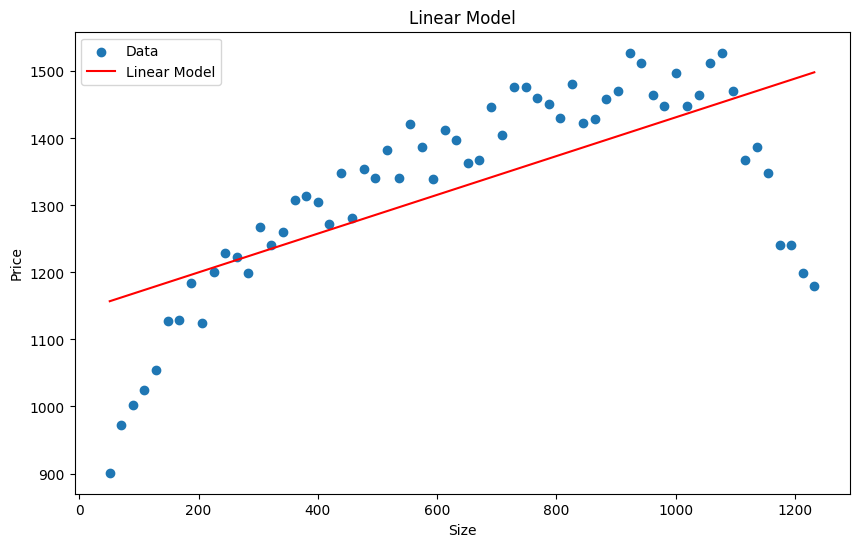


Linear Model R²: 0.4641


In [5]:
# Explore and display the data
print("Dataset:")
print(data.head(10))
print("\nBasic statistics:")
print(data.describe())

plt.figure(figsize=(10, 6))
plt.scatter(data.iloc[:, 0], data.iloc[:, 1])
plt.xlabel('Size')
plt.ylabel('Price')
plt.title('Data')
plt.show()

# Prepare data
X = data.iloc[:, 0].values.reshape(-1, 1)
y = data.iloc[:, 1].values

# Linear model
# Standardize the data
X_mean = X.mean()
X_std = X.std()
X_scaled = (X - X_mean) / X_std

# Create and train a linear model
model_linear = LinearRegression()
model_linear.fit(X_scaled, y)

# Display model parameters
print("\nLinear Model Parameters:")
print(f"Coefficient: {model_linear.coef_[0]:.4f}")
print(f"Intercept: {model_linear.intercept_:.4f}")

# Visualize the linear model
y_pred_linear = model_linear.predict(X_scaled)

plt.figure(figsize=(10, 6))
plt.scatter(X, y, label='Data')
plt.plot(X, y_pred_linear, color='red', label='Linear Model')
plt.xlabel('Size')
plt.ylabel('Price')
plt.title('Linear Model')
plt.legend()
plt.show()

# Display model scores
r2_linear = r2_score(y, y_pred_linear)
print(f"\nLinear Model R²: {r2_linear:.4f}")


# Create a polynomial regression model
- create a polynomial 1D model with steps 2 - 8
- display models
- display their parameters
- show their scores
- Which model would you choose?


Polynomial Degree 2:
R² Score: 0.8808

Polynomial Degree 3:
R² Score: 0.8962

Polynomial Degree 4:
R² Score: 0.9536

Polynomial Degree 5:
R² Score: 0.9549

Polynomial Degree 6:
R² Score: 0.9560

Polynomial Degree 7:
R² Score: 0.9569

Polynomial Degree 8:
R² Score: 0.9589


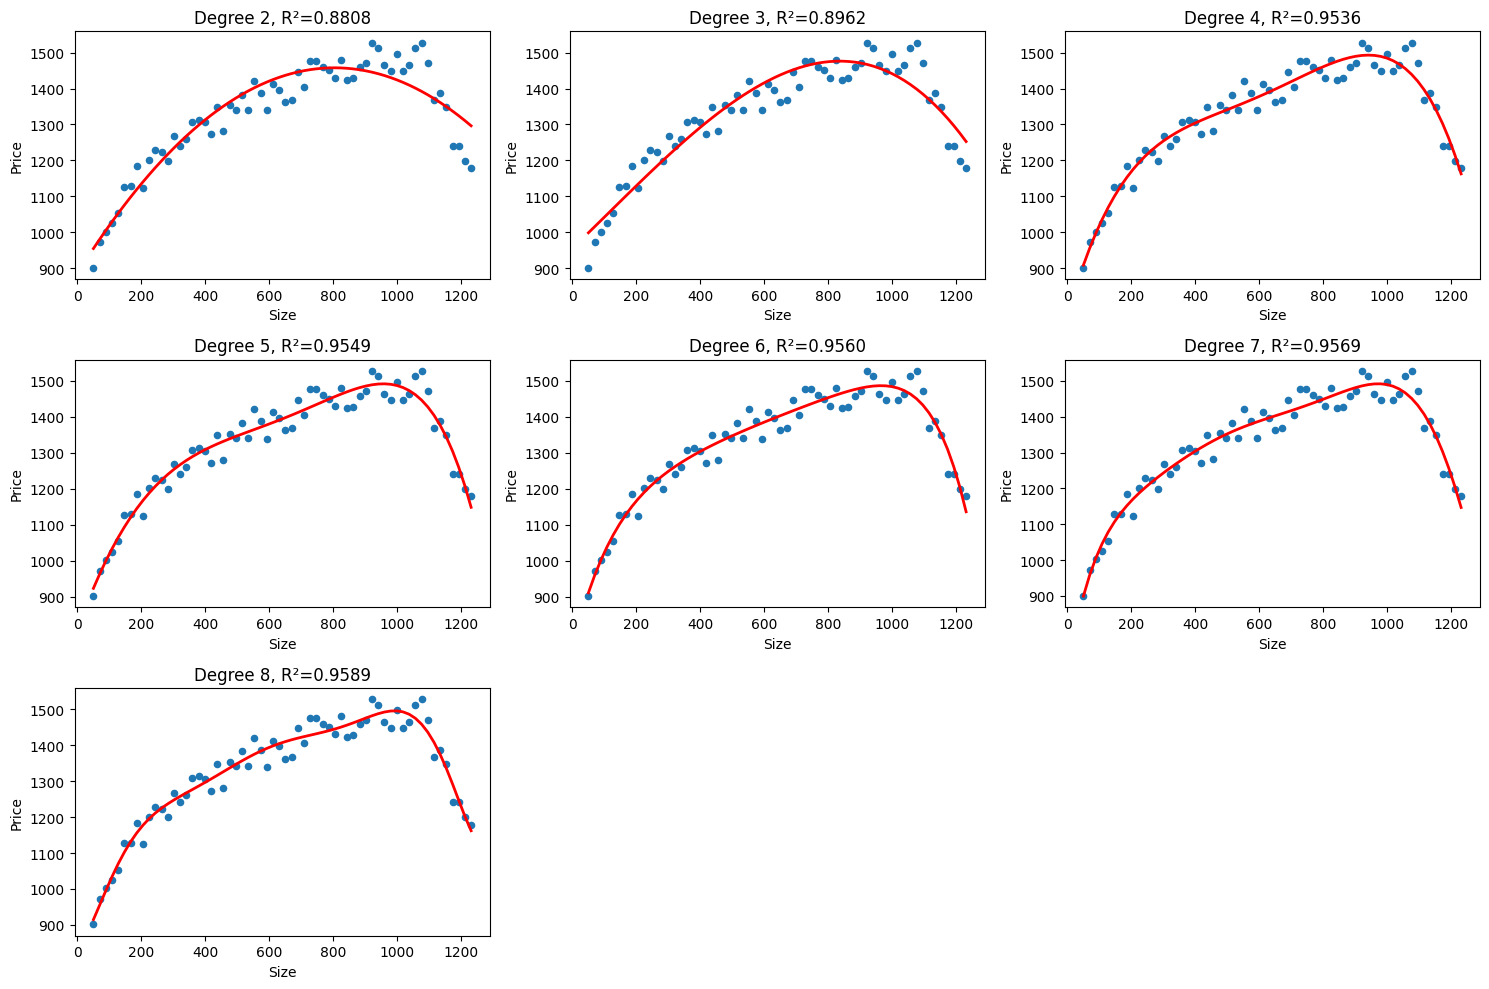

In [9]:
degrees = range(2, 9)

plt.figure(figsize=(15, 10))

for i, degree in enumerate(degrees, 1):
    # Create polynomial features
    X_poly = np.column_stack([X**d for d in range(1, degree + 1)])
    
    # Standardize
    X_poly_mean = X_poly.mean(axis=0)
    X_poly_std = X_poly.std(axis=0)
    X_poly_scaled = (X_poly - X_poly_mean) / X_poly_std
    
    # Create and train model
    model_poly = LinearRegression()
    model_poly.fit(X_poly_scaled, y)
    
    # Predictions
    y_pred_poly = model_poly.predict(X_poly_scaled)
    
    # Display scores
    r2_poly = r2_score(y, y_pred_poly)
    print(f"\nPolynomial Degree {degree}:")
    print(f"R² Score: {r2_poly:.4f}")
    
    # Display model
    plt.subplot(3, 3, i)
    sort_idx = np.argsort(X.flatten())
    X_sorted = X[sort_idx]
    y_pred_sorted = y_pred_poly[sort_idx]
    
    plt.scatter(X, y, s=20)
    plt.plot(X_sorted, y_pred_sorted, color='red', linewidth=2)
    plt.title(f'Degree {degree}, R²={r2_poly:.4f}')
    plt.xlabel('Size')
    plt.ylabel('Price')

plt.tight_layout()
plt.show()
